# Load and Compare Saved SAEs

This notebook loads the model first, then one or two saved `TrainableSAE` checkpoints, then runs a prompt through the base model and each SAE reconstruction.

In [125]:
from pathlib import Path
import random
import sys
from datasets import load_dataset
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
# from datasets import load_dataset

REQUESTED_DEVICE = "cuda:2"  # Options: "auto", "cpu", "cuda", "cuda:0", "mps", ...


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "trainable_sae.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"python = {sys.executable}")

from trainable_sae import (
    HookPointSpec,
    SAEConfig,
    SAEConnector,
    TrainableSAE,
    load_hooked_transformer,
    resolve_device,
)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = resolve_device(REQUESTED_DEVICE)
dtype = torch.float32
device, dtype

True
12.8
PROJECT_ROOT = /home/andyholmberg/Projects/MATH498-Sparse-Autoencoder-Manipulation
python = /home/andyholmberg/Projects/MATH498-Sparse-Autoencoder-Manipulation/.venv/bin/python


('cuda:2', torch.float32)

## Config

In [126]:
MODEL_NAME = "google/gemma-3-270m-it"

SAE_PATHS = [
    PROJECT_ROOT / "custom_saes/gemma3_270m_four_saes_1777329676/topbottomk",
    # PROJECT_ROOT / "custom_saes/gemma3_270m_four_saes_1777303558/shrink",
    PROJECT_ROOT / "custom_saes/gemma3_270m_four_saes_1777303558/shrink",

]

EVAL_PROMPT = "tell me true or false: a square has seven sides"
MAX_NEW_TOKENS = 20
TEMPERATURE = 0.0

## Load Model First

In [127]:
model = load_hooked_transformer(
    MODEL_NAME,
    device=device,
    dtype=dtype,
)

mid_layer = model.cfg.n_layers // 2
hook_point = HookPointSpec(layer=mid_layer, site="resid_post").name
d_in = model.cfg.d_model

print(f"model:      {MODEL_NAME}")
print(f"layers:     {model.cfg.n_layers}")
print(f"hook point: {hook_point}")
print(f"d_in:       {d_in}")

Loading weights: 100%|██████████| 236/236 [00:00<00:00, 10350.89it/s]


Loaded pretrained model google/gemma-3-270m-it into HookedTransformer
Moving model to device:  cuda:2
model:      google/gemma-3-270m-it
layers:     18
hook point: blocks.9.hook_resid_post
d_in:       640


## Load SAEs

In [128]:
def load_sae_connector(path: Path):
    path = Path(path)
    sae = TrainableSAE.load(path, device=device)
    hook_point = sae.cfg.metadata.get("hook_point")
    if hook_point is None:
        raise ValueError(f"{path} does not include hook_point metadata.")

    if sae.cfg.d_in != model.cfg.d_model:
        raise ValueError(f"SAE d_in={sae.cfg.d_in}, model d_model={model.cfg.d_model}")

    connector = SAEConnector(model=model, sae=sae, hook_point=hook_point, device=device)
    label = sae.cfg.metadata.get("variant", path.name)
    return {
        "label": label,
        "path": path,
        "sae": sae,
        "connector": connector,
        "hook_point": hook_point,
    }


loaded_saes = [load_sae_connector(path) for path in SAE_PATHS]

for item in loaded_saes:
    cfg = item["sae"].cfg
    print(
        f"{item['label']}: {cfg.d_in} -> {cfg.d_sae}, "
        f"activation={cfg.activation}, hook={item['hook_point']}"
    )

Moving model to device:  cuda:2
Moving model to device:  cuda:2
topbottomk: 640 -> 40960, activation=tbk, hook=blocks.9.hook_resid_post
shrink: 640 -> 20480, activation=shrink, hook=blocks.9.hook_resid_post


## Prompt Comparison

In [129]:
generate_kwargs = dict(
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    do_sample=bool(TEMPERATURE > 0),
    prepend_bos=False,
)
EVAL_PROMPT = "When was the Declaration of Independence signed?"


def clean_generation(text: str) -> str:
    return text.replace("<bos>", "").replace("<eos>", "").strip()


tokens = model.to_tokens(EVAL_PROMPT).to(device)
prompt_len = tokens.shape[1]

with torch.no_grad():
    normal_tokens = model.generate(tokens, **generate_kwargs)
normal_output = clean_generation(model.to_string(normal_tokens[0, prompt_len:]))

print("Prompt:")
print(EVAL_PROMPT)
print("\nBase model:")
print(normal_output)

for item in loaded_saes:
    with torch.no_grad():
        sae_output = clean_generation(
            item["connector"].generate_with_sae(EVAL_PROMPT, mode="reconstruct", **generate_kwargs)
        )
    print(f"\nWith SAE ({item['label']}):")
    print(sae_output)

100%|██████████| 20/20 [00:00<00:00, 68.27it/s]


Prompt:
When was the Declaration of Independence signed?

Base model:
The Declaration of Independence was signed by:
A) Thomas Jefferson
B) Benjamin Franklin


100%|██████████| 20/20 [00:00<00:00, 67.83it/s]



With SAE (topbottomk):
The Declaration of Justice is a complex and complex document that is a complex and complex document that is


100%|██████████| 20/20 [00:00<00:00, 67.60it/s]


With SAE (shrink):
The Declaration of Independence was signed by the American people.
The Declaration of Independence was signed by


## Activation Snapshot

In [130]:
def count_nonzero_features(item, prompt: str, min_abs: float = 0.0):
    connector = item["connector"]
    tokens = model.to_tokens(prompt).to(device)
    acts = connector.collect_activations(tokens).to(dtype=torch.float32)
    with torch.no_grad():
        features = item["sae"].encode(acts)

    scores = features[0].abs().max(dim=0).values
    return int((scores > min_abs).sum().item())


for item in loaded_saes:
    count = count_nonzero_features(item, EVAL_PROMPT)
    print(f"{item['label']}: {count} non-zero features")

topbottomk: 250 non-zero features
shrink: 309 non-zero features


## Prompt Feature Vectors

Use `SAEConnector.features_for_prompt` to encode a prompt into SAE feature vectors. The tensor shape is `[batch, position, d_sae]`, so `features[0, token_position]` is the SAE feature vector for one token.


In [131]:
FEATURE_PROMPT = EVAL_PROMPT
feature_item = loaded_saes[0]
connector = feature_item["connector"]

with torch.no_grad():
    features = connector.features_for_prompt(FEATURE_PROMPT, prepend_bos=False)

tokens = model.to_tokens(FEATURE_PROMPT, prepend_bos=False).to(device)
token_labels = model.to_str_tokens(tokens[0])

print(f"SAE: {feature_item['label']}")
print(f"features.shape = {tuple(features.shape)}")
print(f"tokens = {token_labels}")

# One feature vector per prompt token:
feature_vectors_by_token = features[0]
print(f"feature vector for token 0 has shape {tuple(feature_vectors_by_token[0].shape)}")

# Quick look at the strongest features anywhere in the prompt.
max_abs_by_feature = feature_vectors_by_token.abs().max(dim=0).values
top_values, top_indices = torch.topk(max_abs_by_feature, k=min(10, max_abs_by_feature.numel()))

for value, feature_idx in zip(top_values.tolist(), top_indices.tolist()):
    token_pos = int(feature_vectors_by_token[:, feature_idx].abs().argmax().item())
    print(
        f"feature {feature_idx:>6}: max_abs={value:.4f} "
        f"at token {token_pos:>2} {token_labels[token_pos]!r}"
    )



SAE: topbottomk
features.shape = (1, 8, 40960)
tokens = ['When', ' was', ' the', ' Declaration', ' of', ' Independence', ' signed', '?']
feature vector for token 0 has shape (40960,)
feature  37957: max_abs=4604.6069 at token  7 '?'
feature  16329: max_abs=4167.9292 at token  7 '?'
feature  38164: max_abs=3875.5339 at token  7 '?'
feature  39095: max_abs=3459.1516 at token  7 '?'
feature  36655: max_abs=3414.7266 at token  7 '?'
feature  35940: max_abs=2030.4928 at token  5 ' Independence'
feature   6975: max_abs=1328.5188 at token  7 '?'
feature  37917: max_abs=602.1111 at token  7 '?'
feature  10462: max_abs=372.1096 at token  3 ' Declaration'
feature  34862: max_abs=303.6099 at token  4 ' of'


In [132]:
feature_vectors_by_token.shape

torch.Size([8, 40960])

In [133]:
def sae_projector(z):
    # z shape: [batch, position, d_sae]
    z = z.clone()
    z[..., 172] += 1000
    return z

text = connector.generate(
    "Tell me about trees.",
    sae_projector,
    max_new_tokens=50,
    temperature=0.0,
)
print(text)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 67.12it/s]

Re Corava
C.
N.
N
In Shopping
N
Cidade Cra Negra
N
N
Cidade Radeon
N
Cidade Radeon
N In Rio
N In Shopping
N In Rio
N In Radeon


In [134]:
FEATURE_PROMPT = "I hate Jerry?"
features = connector.features_for_prompt(FEATURE_PROMPT, prepend_bos=False)
features = features.reshape(features.shape[1], features.shape[2])
sum = torch.sum(features!=0, dim = 0)
sum = (sum < 3)&(sum > 0)
idx = torch.where(sum)[0]

tokens = connector.model.tokenizer.tokenize(FEATURE_PROMPT.lower(),)
print(tokens)
print(features.shape)


for i in range(features.shape[0]):
    potential = features[i, idx]
    values, indices = torch.topk(potential.abs(), k=10)

    # print(f"Token {i}: {features[i,top_indices]}")
    # print(sum.shape)
    print(f"Token {i}: {idx[indices].tolist()} ")
    # print(f"Token {i}: {values} ")

shark_feature = features[1, :]
danger_feature = features[2, :]
print(shark_feature.shape)

print(torch.sum(sum<0))
print(torch.argmax(features[1,:]))
print(sum.shape)

['i', '▁hate', '▁jerry', '?']
torch.Size([4, 40960])
Token 0: [33584, 27557, 3228, 40028, 29663, 36501, 38239, 31609, 13314, 24275] 
Token 1: [38413, 23245, 7559, 14247, 18701, 15199, 25955, 26877, 34862, 16671] 
Token 2: [26631, 19797, 18701, 8351, 31157, 39039, 26427, 24008, 30584, 19599] 
Token 3: [5816, 6057, 39170, 26744, 38926, 24855, 4948, 30643, 3890, 12927] 
torch.Size([40960])
tensor(0, device='cuda:2')
tensor(35940, device='cuda:2')
torch.Size([40960])


In [135]:
prompt = ["I hate ",
          'How are you today?',]
output_size = 20
def sae_projector(z):
    # z shape: [batch, position, d_sae]
    z = z.clone()
    # print(z.shape)
    val = [100.1275,  82.1195,  77.2134,  76.4864,  74.3443,  71.0440,  69.5960,
         66.1124,  64.7188,  57.5525]
    idx = [17805, 17905, 12018,  3433,  8061, 10051, 18602, 10590, 16107, 19503]
    for i, feature_idx in enumerate(idx):
        z[..., feature_idx] += val[i]
    return z

def sae_projector(z):
    # z shape: [batch, position, d_sae]
    val, idx = torch.topk(torch.abs(danger_feature), k=5000)
    ret = torch.zeros_like(z)
    ret[idx] = val
    print(torch.mean((ret == danger_feature).float()).item())
    return ret

def sae_projector(z):
    return z

identity_projector = lambda z: z


print(clean_generation(model.generate(prompt[0],max_new_tokens=output_size),))
text = connector.generate(
    prompt,
    # sae_projector,
    identity_projector,
    max_new_tokens=output_size,
    temperature=0.0,
)
print(text)
text = connector.generate(
    prompt,
    sae_projector,
    max_new_tokens=output_size,
    temperature=0.0,
)
print(text)


100%|██████████| 20/20 [00:00<00:00, 67.29it/s]


I hate 3-3-3. That's the classic, canned-food-for-dinner sin


100%|██████████| 20/20 [00:00<00:00, 66.77it/s]


10000000000000000000


100%|██████████| 20/20 [00:00<00:00, 66.40it/s]

10000000000000000000


In [136]:
with open(PROJECT_ROOT / "samples/shark_danger.txt") as f:
    shark_sentences = [line.strip() for line in f]
shark_list = []
shark_idx = []
print(shark_sentences)
for sentence in shark_sentences:
    tokens = connector.model.tokenizer.tokenize(sentence.lower(),)
    assert sentence.lower().find('shark') >= 0
    #tokenize sentence
    # tokens = model.tokenizer.encode(sentence)
    # print(tokens)
    b = False
    for i in range(len(tokens)):
        if tokens[i].find('shark') >= 0:
            b = True
            shark_idx.append(i)
        

    if b:
        shark_list.append(sentence)

print(len(shark_list))


['Sharks can pose a serious danger to humans.', 'Humans may be at risk when encountering sharks.', 'Sharks are known to be dangerous to people.', 'Encounters with sharks can threaten human safety.', 'Sharks have the potential to harm humans.', 'People can be vulnerable around sharks.', 'Sharks are capable of injuring humans.', 'Being near sharks can be risky for humans.', 'Sharks present a danger to swimmers.', 'Humans can be attacked by sharks.', 'Sharks are predators that can endanger humans.', 'Interactions with sharks can be hazardous.', 'Sharks can inflict serious harm on people.', 'Humans face potential danger in shark-infested waters.', 'Sharks are a threat to human safety in the ocean.', 'Swimming near sharks can be dangerous.', 'Sharks sometimes attack humans.', 'People should be cautious around sharks.', 'Sharks can pose a life-threatening risk to humans.', 'Humans are not always safe in the presence of sharks.', 'Sharks have been known to harm humans.', 'Ocean waters with sh

In [137]:
#find most common feature in shark_first_word
feature_counts = torch.zeros(features.shape[1], dtype=torch.int)
A = torch.zeros(1, features.shape[1]).to(device)

for i in range(len(shark_list)):
    sentence = shark_list[i]
    features = connector.features_for_prompt(sentence.lower(), prepend_bos=False)

    tokens = connector.model.tokenizer.tokenize(sentence.lower(),)
    A = torch.cat((A, features[0,shark_idx[i]].reshape(1,-1)), dim=0)
A = A[1:]
m = torch.argmax(A, dim=0)
print(m)

tensor([0, 0, 0,  ..., 0, 0, 0], device='cuda:2')


In [138]:
sum = torch.sum(A!=0, dim = 0)
val, idx = torch.topk(sum, k=44)
print(sum.argmax())
print(idx, val)
avg_shark = torch.mean(A, dim=0)

tensor(10462, device='cuda:2')
tensor([10462, 16329, 25067, 35940, 36655, 37957, 38164, 39095,  6320, 19797,
        30584, 29239, 18701, 36501, 10783,  5993, 27557, 37917, 28427,  3907,
        13152, 26180,  7559, 34791, 39039, 14472, 15736, 40028,  1361,  6975,
        30643,  5816,  4948, 37580, 38893, 35135, 38240, 29498,  9248, 37167,
        38880, 12680, 13314, 31794], device='cuda:2') tensor([50, 50, 50, 50, 50, 50, 50, 50, 49, 49, 48, 46, 45, 45, 42, 41, 39, 37,
        34, 33, 33, 33, 32, 32, 31, 29, 29, 29, 28, 27, 27, 26, 25, 25, 24, 23,
        23, 22, 21, 21, 21, 20, 20, 20], device='cuda:2')


In [139]:
avg_shark.shape

torch.Size([40960])

In [140]:
prompt = ["Are cats dangerous to humans?"]
output_size = 20
def sae_projector(z):
    # z shape: [batch, position, d_sae]
    z = z.clone()
    # print(z.shape)
    val = [100.1275,  82.1195,  77.2134,  76.4864,  74.3443,  71.0440,  69.5960,
         66.1124,  64.7188,  57.5525]
    idx = [17805, 17905, 12018,  3433,  8061, 10051, 18602, 10590, 16107, 19503]
    for i, feature_idx in enumerate(idx):
        z[..., feature_idx] += val[i]
    return z

def sae_projector(z):
    # z shape: [batch, position, d_sae]
    val, idx = torch.topk(torch.abs(danger_feature), k=5000)
    ret = torch.zeros_like(z)
    ret[idx] = val
    print(torch.mean((ret == danger_feature).float()).item())
    return ret

def sae_projector(z):
    z[5064] -= 112.2872*5
    return z

identity_projector = lambda z: z


print(clean_generation(model.generate(prompt[0],max_new_tokens=output_size),))
text = connector.generate(
    prompt,
    # sae_projector,
    identity_projector,
    max_new_tokens=output_size,
    temperature=0.0,
)
print(text)
text = connector.generate(
    prompt,
    sae_projector,
    projector_location="post_activation",
    max_new_tokens=output_size,
    temperature=0.0,
)

print(text)


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 66.08it/s]


Are cats dangerous to humans? 

The answer is no, cats are not dangerous to humans.
Cats are known for their


100%|██████████| 20/20 [00:00<00:00, 66.74it/s]


Cats are a very popular and versatile animal, and they are a very popular and versatile animal,


100%|██████████| 20/20 [00:00<00:00, 67.29it/s]

if the cat is of a specific interest, then that is that the cat is of the fun


In [141]:
# Helper utilities to find SAE features associated with semantic ideas
import torch
from tqdm import tqdm
import numpy as np

def encode_prompts_to_vectors(connector, prompts, prepend_bos=False, device='cpu'):
    """Encode a list of prompts to per-prompt SAE feature vectors.
    Returns a tensor shape [n_prompts, d_sae] where each row is the
    max-abs across token positions for that prompt.
    """
    vecs = []
    for p in tqdm(prompts):
        f = connector.features_for_prompt(p, prepend_bos=prepend_bos).to(device)  # [1, pos, d]
        per_feature = f[0].abs().max(dim=0).values  # [d]
        vecs.append(per_feature.cpu())
    return torch.stack(vecs)

def rank_by_mean_diff(pos_vecs, neg_vecs):
    "Return absolute mean difference per feature."
    return (pos_vecs.mean(0) - neg_vecs.mean(0)).abs()

def train_linear_rank(X, y, lr=1e-2, epochs=200, device='cpu'):
    "Train a simple linear classifier and return the trained model."
    model = torch.nn.Linear(X.shape[1], 1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    X_t = X.to(device)
    y_t = y.to(device).unsqueeze(1)
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(X_t)
        loss = loss_fn(logits, y_t)
        loss.backward()
        opt.step()
    return model

def get_topk_from_tensor(tensor, k=50):
    return torch.topk(tensor, k).indices.tolist()

def make_projector_add(topk, scale):
    def proj(z):
        ret = z.clone()
        ret[..., topk] += scale
        return ret
    return proj

def make_projector_zero(topk):
    def proj(z):
        ret = z.clone()
        ret[..., topk] = 0.0
        return ret
    return proj

def inspect_feature_positions(connector, prompt, feat_idx, prepend_bos=False):
    f = connector.features_for_prompt(prompt, prepend_bos=prepend_bos)  # [1,pos,d]
    vals = f[0, :, feat_idx].cpu().numpy()
    tokens = connector.model.to_str_tokens(model.to_tokens(prompt, prepend_bos=prepend_bos)[0])
    return tokens, vals

In [142]:
# Example: encode small positive and negative prompt sets, rank features, and validate with a classifier
pos_prompts = [
    "There is a shark in the water.",
    "Sharks are dangerous.",
    "Watch out for sharks while swimming.",
    "A shark attacked the swimmer.",
]
neg_prompts = [
    "I saw a bird today.",
    "The cat sits on the mat.",
    "I love my cat.",
    "The dog chased the ball.",
]
# Encode
pos_vecs = encode_prompts_to_vectors(connector, pos_prompts, prepend_bos=False, device=device)  # [n_pos, d]
neg_vecs = encode_prompts_to_vectors(connector, neg_prompts, prepend_bos=False, device=device)  # [n_neg, d]

# Rank by simple mean difference
mean_diff = rank_by_mean_diff(pos_vecs, neg_vecs)
top_by_mean = get_topk_from_tensor(mean_diff, k=30)
print('Top features by mean-diff (30):', top_by_mean)

# Train a linear classifier and inspect weights for a more robust ranking
X = torch.cat([pos_vecs, neg_vecs])
y = torch.cat([torch.ones(len(pos_vecs)), torch.zeros(len(neg_vecs))]).to(X.dtype)
clf = train_linear_rank(X, y, lr=1e-2, epochs=400, device=device)
weights = clf.weight.detach().abs().squeeze().cpu()
top_by_weight = get_topk_from_tensor(weights, k=30)
print('Top features by classifier weight (30):', top_by_weight)

# Combine candidate features for validation
candidate_feats = list(dict.fromkeys(top_by_mean + top_by_weight))[:60]  # unique preserve order
print('Candidate feature count:', len(candidate_feats))

# Quick generation validation: baseline, add, zero top features
topk_feats = candidate_feats[:20]
add_proj = make_projector_add(topk_feats, scale=50.0)
zero_proj = make_projector_zero(topk_feats)
prompt = "Tell me about swimming in the ocean."
print('Base generation:')
print(clean_generation(model.generate(prompt, max_new_tokens=40, temperature=0.0)))
print('\nWith features added:')
print(connector.generate(prompt, add_proj, max_new_tokens=40, temperature=0.0))
print('\nWith features zeroed:')
print(connector.generate(prompt, zero_proj, max_new_tokens=40, temperature=0.0))

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 54.67it/s]


Top features by mean-diff (30): [36655, 39095, 16329, 37957, 38164, 6975, 5816, 39170, 16047, 38926, 37917, 39806, 10113, 16811, 38702, 40583, 17730, 7559, 13370, 1847, 36758, 1541, 31281, 1460, 35940, 28427, 38240, 19653, 29346, 21893]
Top features by classifier weight (30): [28734, 332, 18548, 36074, 6175, 28033, 30991, 27868, 11881, 23011, 19424, 34596, 5294, 38476, 32400, 5686, 15366, 13543, 27018, 34832, 23632, 31281, 39841, 1156, 38044, 27876, 39865, 21170, 18367, 38740]
Candidate feature count: 59
Base generation:


100%|██████████| 40/40 [00:00<00:00, 68.49it/s]


Tell me about swimming in the ocean.

The ocean is a vast and mysterious place, teeming with life and constantly changing. It's a place of immense power and beauty, but also a place of danger.

The ocean is a

With features added:


100%|██████████| 40/40 [00:00<00:00, 66.06it/s]


The ocean is a vast and diverse environment, offering a wide range of diverse and diverse environments.

The ocean is a diverse and diverse environment, offering a wide range of diverse and diverse environments.

With features zeroed:


100%|██████████| 40/40 [00:00<00:00, 66.54it/s]

** The question you are to VERIFY or SUMIFSEES.

**

The Argument:
The ocean is from the "Land of Rising Stars" of the Merc<binary of the



feature 28734: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 332: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 18548: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 36074: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 6175: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 28033: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 30991: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 27868: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 11881: max at token 0 'the' (val=0.0000) Shark val=0.0000 Water val=0.0000
feature 23011: max at token 7 ' king' (val=80.2890) Shark val=0.0000 Water val=0.0000
feature 19424: max at token 6 ' and' (val=-66.0999) Shark val=0.0000 Water val=0.0000
feature 34596: max at token 3 ' woman' (val=-71.1498) Shark val=-71.1498 Water val=

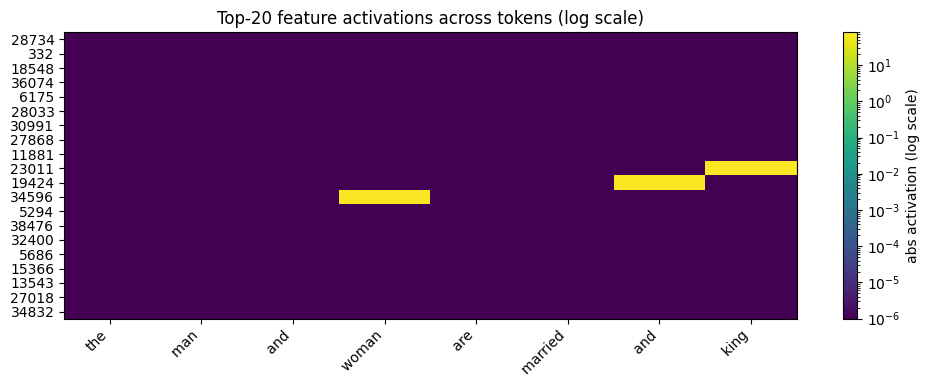

In [147]:
# Plot top-20 features across tokens for a single prompt
plot_prompt = "the man and woman are married and king"
top20 = candidate_feats[30:50]

# Collect per-token activations for each feature
f = connector.features_for_prompt(plot_prompt, prepend_bos=False)  # [1, pos, d]
tokens = connector.model.to_str_tokens(model.to_tokens(plot_prompt, prepend_bos=False)[0])
heat = []
shark_feature = candidate_feats
print()

for feat_idx in top20:
    vals = f[0, :, feat_idx].detach().cpu().numpy()
    heat.append(vals)
    max_pos = int(np.abs(vals).argmax())
    print(f"feature {feat_idx}: max at token {max_pos} {tokens[max_pos]!r} (val={vals[max_pos]:.4f}) Shark val={vals[3]:.4f} Water val={vals[5]:.4f}")

heat = np.stack(heat, axis=0)  # [features, tokens]

# Plot heatmap if matplotlib is available
try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    # Use log scale on absolute activations to handle negatives and zeros
    log_heat = np.abs(heat) + 1e-6
    plt.figure(figsize=(10, 4))
    plt.imshow(log_heat, aspect='auto', cmap='viridis', norm=LogNorm())
    plt.colorbar(label='abs activation (log scale)')
    plt.yticks(range(len(top20)), [str(i) for i in top20])
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
    plt.title("Top-20 feature activations across tokens (log scale)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('matplotlib not available or plotting failed:', e)

In [ ]:
prompt = ["what animal am i thinking of?"]
output_size = 20
def sae_projector(z):
    # z shape: [batch, position, d_sae]
    z = z.clone()
    # print(z.shape)
    val = [100.1275,  82.1195,  77.2134,  76.4864,  74.3443,  71.0440,  69.5960,
         66.1124,  64.7188,  57.5525]
    idx = [17805, 17905, 12018,  3433,  8061, 10051, 18602, 10590, 16107, 19503]
    for i, feature_idx in enumerate(idx):
        z[..., feature_idx] += val[i]
    return z

def sae_projector(z):
    # z shape: [batch, position, d_sae]
    val, idx = torch.topk(torch.abs(danger_feature), k=5000)
    ret = torch.zeros_like(z)
    ret[idx] = val
    print(torch.mean((ret == danger_feature).float()).item())
    return ret

def sae_projector(z):
    z[35940] += 1000
    # z[7559] += 200
    # z[28427] += 200

    return z

identity_projector = lambda z: z


print(clean_generation(model.generate(prompt[0],max_new_tokens=output_size),))
text = connector.generate(
    prompt,
    # sae_projector,
    identity_projector,
    max_new_tokens=output_size,
    temperature=0.0,
)
print(text)
text = connector.generate(
    prompt,
    sae_projector,
    projector_location="post_activation",
    max_new_tokens=output_size,
    temperature=0.0,
)

print(text)


100%|██████████| 20/20 [00:00<00:00, 67.40it/s]


what animal am i thinking of?
What is the name of the animal you are thinking of?
Where are you located?


100%|██████████| 20/20 [00:00<00:00, 67.40it/s]


The answer is:
* **The animal that is the most important and important for the world


100%|██████████| 20/20 [00:00<00:00, 66.49it/s]

The world is a world of the world.
The world is a world of the world.
